In [1]:
import os 
os.environ["OMP_NUM_THREADS"] = "50"

In [2]:
import torch
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(["science"])

plt.rcParams.update({'font.size': 12})
plt.rcParams.update({
    "text.usetex": True,        
    "font.family": "serif",     
    "font.serif": ["Times"],
    "figure.dpi": 300,          
    "axes.grid": True, 
    "grid.linestyle": "--",
    "grid.linewidth": 0.1,
    "grid.alpha": 0.05,
    "grid.linestyle": "--",     
})
from ps_utils import map2cl, get_lxly
from scipy.ndimage import gaussian_filter
from scipy.fft import fft2,fftshift
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter1d

In [3]:
RES = 256
STEP_SIZE = 6
ANG_X = 6.
ANG_Y = 6. 
flatskymapparams = [RES, RES, 60.*ANG_X/RES, 60.*ANG_X/RES] #Needs pixelres to be in arcmin
nx,ny,dx,dy = flatskymapparams
dx_rad = np.radians(dx/60.)
dy_rad = np.radians(dy/60.)
lx, ly = get_lxly(flatskymapparams)

ptsrc=2

In [4]:
lx=lx[0]
ly = ly[:,0]

# Loading and plotting

In [5]:
fpath_cib = f"data/low_pass/{ptsrc}mJy/CIB_map_150GHz_256_st6_minmax_{ptsrc}mJy_zero_lp.npy"
fpath_tsz = f"data/low_pass/{ptsrc}mJy/tSZ3_map_150GHz_256_st6_minmax_{ptsrc}mJy_norm_lp.npy"

cib_maps = np.load(fpath_cib)  # (N, H, W, 1)
tsz_maps = np.load(fpath_tsz)  # (N, H, W, 1)

# Stack along channel axis: (N, H, W, 2)
cut_maps = np.concatenate([cib_maps, tsz_maps], axis=-1)
cut_maps = cut_maps.transpose(0, 3, 1, 2)  # (N, 2, H, W)


In [20]:
np.max(cib_maps)

np.float32(1.0)

In [6]:
print("Total Maps = : ", len(cut_maps))
num_samples = len(cut_maps)

Total Maps = :  1041


In [8]:
num_train = int(0.8 * num_samples)
rng = np.random.default_rng(seed=42)
indices = rng.permutation(num_samples)
train_indices = indices[:num_train]
test_indices = indices[num_train:]
training_images = torch.tensor(cut_maps[train_indices], dtype=torch.float32)
testing_images = torch.tensor(cut_maps[test_indices], dtype=torch.float32)

In [9]:
print(np.min(cut_maps[train_indices]),np.max(cut_maps[train_indices]),np.mean(cut_maps[train_indices]))
print(np.min(cut_maps[test_indices]),np.max(cut_maps[test_indices]),np.mean(cut_maps[test_indices]))

0.0 1.0 0.5727397
0.0 1.0 0.57274646


In [10]:
training_images = training_images.permute(0, 2, 3, 1)
testing_images = testing_images.permute(0, 2, 3, 1)

In [13]:
all_samples = np.load("data/low_pass/2mJy/new_samples_20_cib_2mJy_zero_6x6_w_au_lp.npy")
#all_samples = np.load("data/low_pass/6mJy/new_samples_23_cib_6mJy_zero_6x6_w_au_lp.npy")
#all_samples = np.load("data/low_pass/2mJy/new_samples_12_cib_tsz_2mJy_zero_norm_6x6_w_au_lp.npy")
#all_samples = np.load("data/low_pass/2mJy/new_samples_16_cib_tsz3_2mJy_zero_norm_6x6_w_au_lp.npy")

In [14]:
len(all_samples),np.min(all_samples),np.max(all_samples),np.mean(all_samples),np.std(all_samples)

(960,
 np.float32(0.0),
 np.float32(1.0),
 np.float32(0.5715174),
 np.float32(0.39552426))

In [16]:
all_samples = 224.06384 #cib+tSZ
#all_samples *= 158.31772 #cib+tSZ3
#110.732285

In [17]:
np.min(cut_maps),np.max(cut_maps),np.mean(cut_maps)

(np.float32(0.0), np.float32(1.0), np.float32(0.57274413))

In [18]:
np.min(all_samples),np.max(all_samples),np.mean(all_samples)

(np.float32(0.0), np.float32(158.31772), np.float32(90.48105))

In [172]:
np.std(cut_maps)

np.float32(5.843648)

In [173]:
np.std(all_samples)

np.float32(5.4096055)

In [174]:
all_samples = ((all_samples - np.mean(all_samples))*(np.std(cut_maps)/np.std(all_samples))) + np.mean(all_samples)
#all_samples -= np.min(all_samples)
#all_samples *= 110.732285
#all_samples *= 59.062283

In [175]:
np.min(all_samples),np.max(all_samples),np.mean(all_samples)

(np.float32(-1.6002178), np.float32(148.85698), np.float32(19.944038))

In [136]:
gaussian_maps = np.load("data/low_pass/6mJy/cut_maps_RES_256_ANG_X_6.0 deg_6mJy_lp_gaussian.npy")

In [158]:
img_diff = all_samples[0][0] 
img_test = training_images[0, :, :, 0].cpu().numpy()
img_gaussian = gaussian_maps[0][:,:,0]

img_diff -= np.mean(img_diff)
img_test -= np.mean(img_test)
img_gaussian -= np.mean(img_gaussian)

smoothed_diff = gaussian_filter(img_diff, sigma=10)
smoothed_test = gaussian_filter(img_test, sigma=10)
smoothed_gaussian = gaussian_filter(img_gaussian, sigma=10)

img_diff_hp = img_diff - smoothed_diff
img_test_hp = img_test - smoothed_test
img_gaussian_hp = img_gaussian - smoothed_gaussian

fft_diff = fftshift(fft2(img_diff) * dx_rad / nx)
fft_test = fftshift(fft2(img_test) * dx_rad / nx)
fft_gaussian = fftshift(fft2(img_gaussian) * dx_rad / nx)

center_diff = (fft_diff.shape[0] // 2, fft_diff.shape[1] // 2)
fft_diff[center_diff] = 1e-10
center_test = (fft_test.shape[0] // 2, fft_test.shape[1] // 2)
fft_test[center_test] = 1e-10
center_gaussian = (fft_gaussian.shape[0] // 2, fft_gaussian.shape[1] // 2)
fft_gaussian[center_gaussian] = 1e-10

fft_diff_log = gaussian_filter(np.log10(np.abs(fft_diff)), sigma=1)
fft_test_log = gaussian_filter(np.log10(np.abs(fft_test)), sigma=1)
fft_gaussian_log = gaussian_filter(np.log10(np.abs(fft_gaussian)), sigma=1)
extent_val = [np.min(lx), np.max(lx), np.min(ly), np.max(ly)]

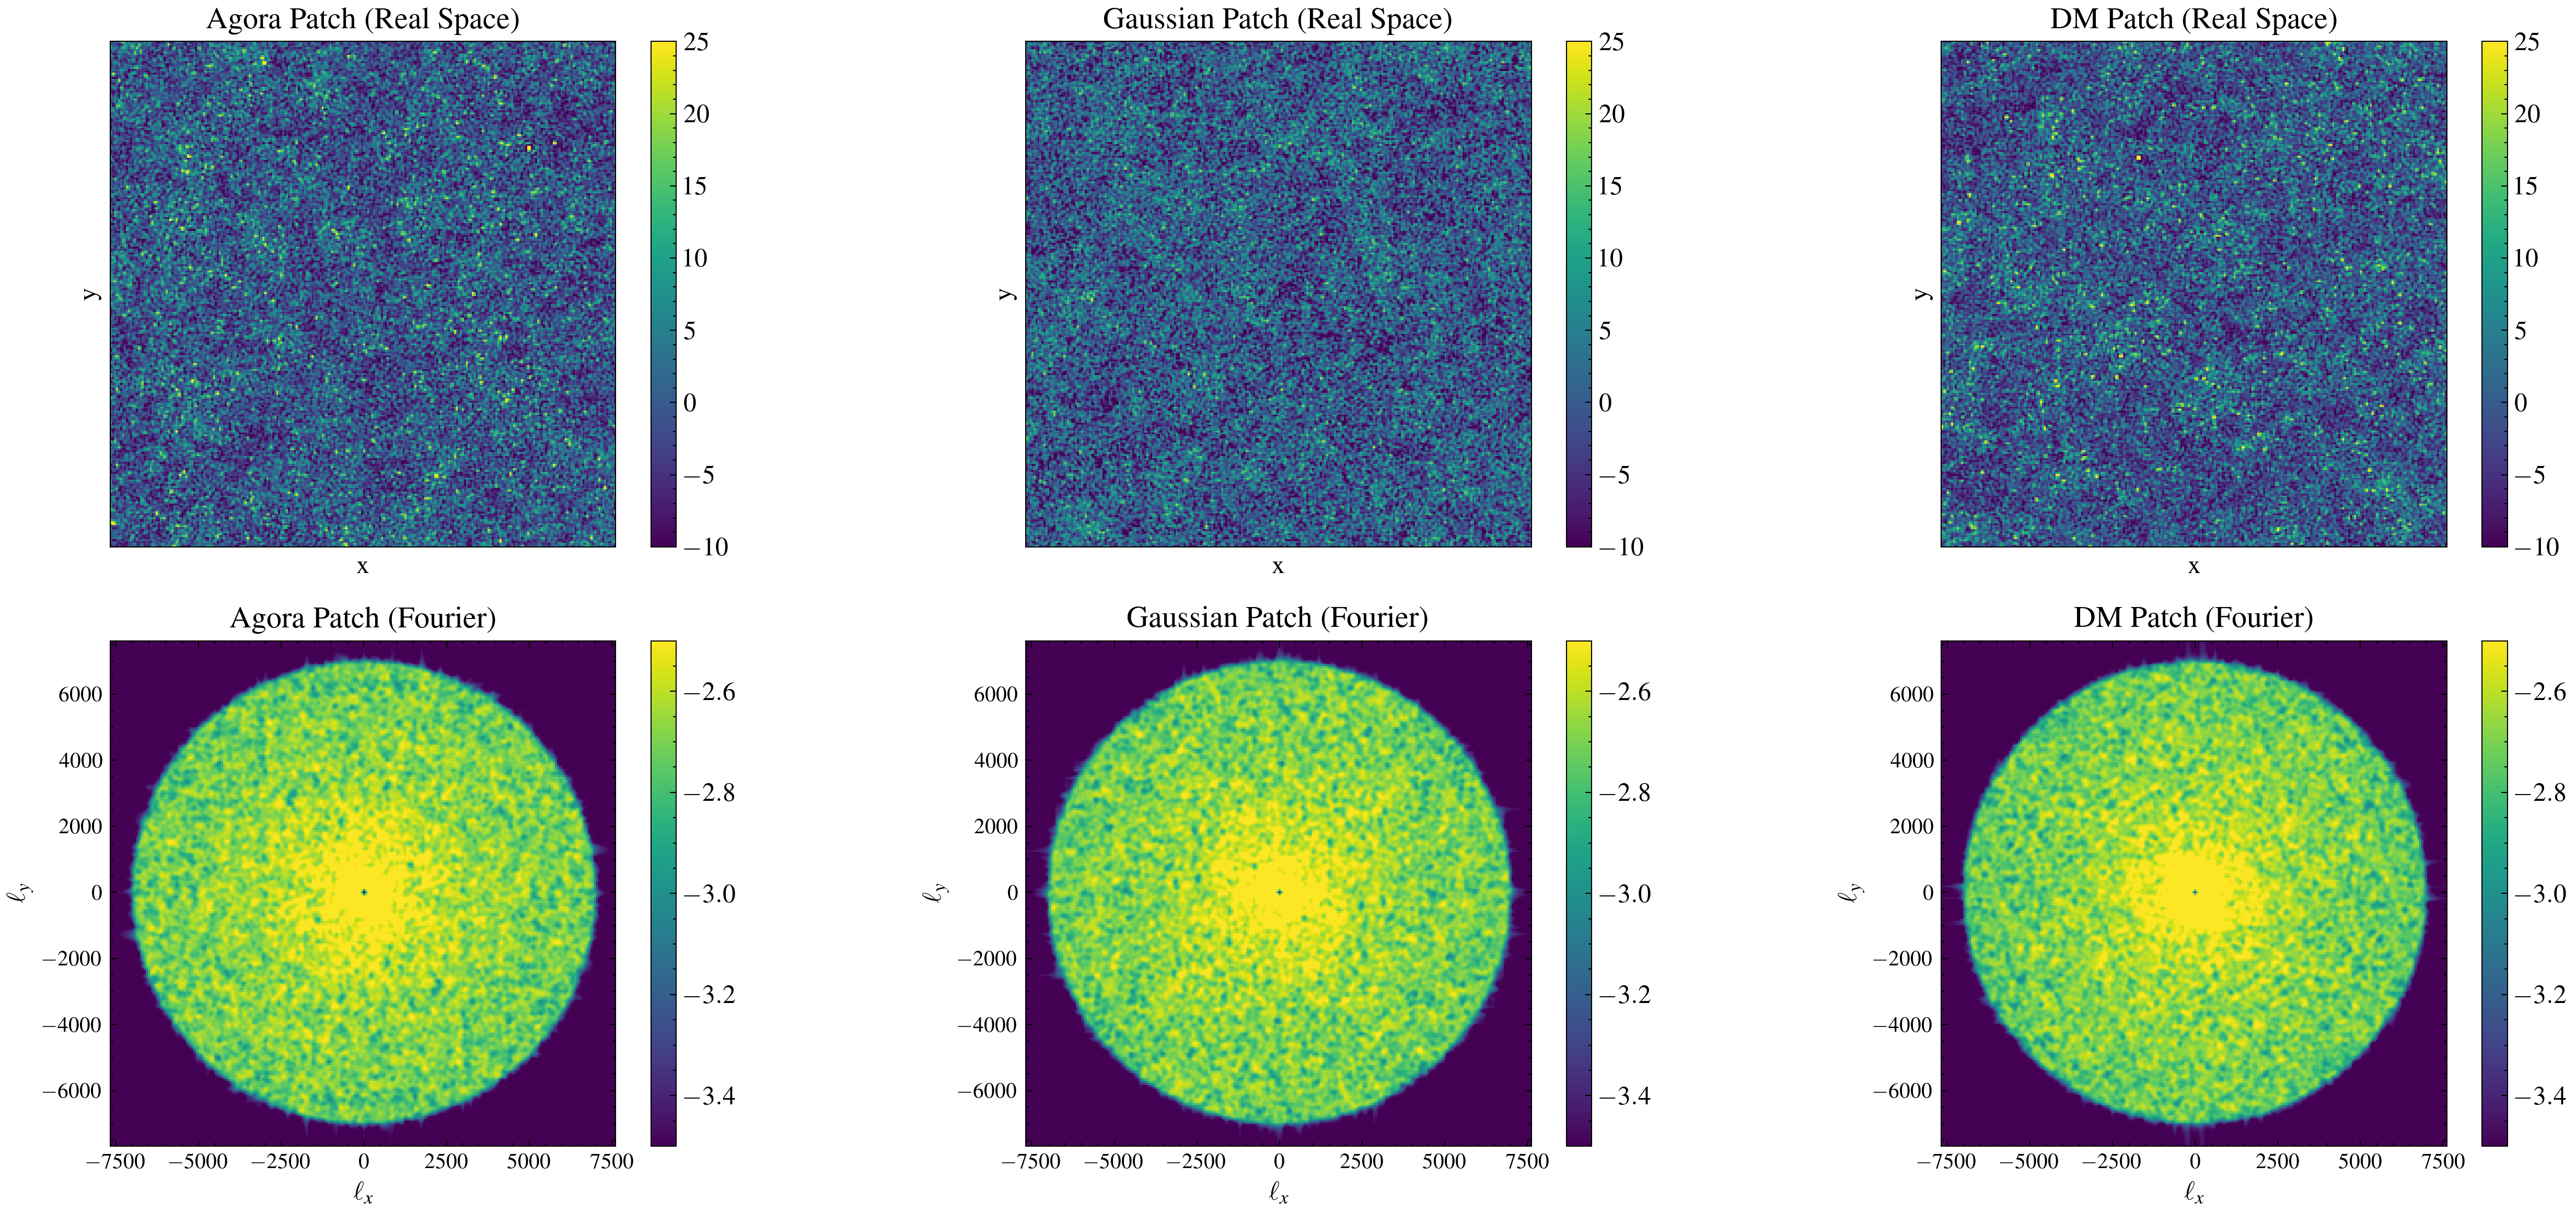

In [159]:
fig, axs = plt.subplots(2, 3, figsize=(18, 8))

im0 = axs[0, 0].imshow(img_test, cmap='viridis', vmin=-10, vmax=25)
axs[0, 0].set_title("Agora Patch (Real Space)", fontsize=14)
axs[0, 0].set_xlabel("x", fontsize=12)
axs[0, 0].set_ylabel("y", fontsize=12)
axs[0, 0].set_xticks([])
axs[0, 0].set_yticks([])
fig.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.04)

im1 = axs[0, 1].imshow(img_gaussian, cmap='viridis', vmin=-10, vmax=25)
axs[0, 1].set_title("Gaussian Patch (Real Space)", fontsize=14)
axs[0, 1].set_xlabel("x", fontsize=12)
axs[0, 1].set_ylabel("y", fontsize=12)
axs[0, 1].set_xticks([])
axs[0, 1].set_yticks([])
fig.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.04)

im2 = axs[0, 2].imshow(img_diff, cmap='viridis', vmin=-10, vmax=25)
axs[0, 2].set_title("DM Patch (Real Space)", fontsize=14)
axs[0, 2].set_xlabel("x", fontsize=12)
axs[0, 2].set_ylabel("y", fontsize=12)
axs[0, 2].set_xticks([])
axs[0, 2].set_yticks([])
fig.colorbar(im2, ax=axs[0, 2], fraction=0.046, pad=0.04)

im3 = axs[1, 0].imshow(fft_test_log, cmap='viridis', vmin=-3.5, vmax=-2.5,
                        extent=extent_val, origin='lower')
axs[1, 0].set_title("Agora Patch (Fourier)", fontsize=14)
axs[1, 0].set_xlabel(r"$\ell_x$", fontsize=12)
axs[1, 0].set_ylabel(r"$\ell_y$", fontsize=12)
axs[1, 0].tick_params(axis='both', labelsize=10)
axs[1, 0].grid(True, which='both', ls=':', lw=0.5, color='gray')
fig.colorbar(im3, ax=axs[1, 0], fraction=0.046, pad=0.04)

im4 = axs[1, 1].imshow(fft_gaussian_log, cmap='viridis', vmin=-3.5, vmax=-2.5,
                        extent=extent_val, origin='lower')
axs[1, 1].set_title("Gaussian Patch (Fourier)", fontsize=14)
axs[1, 1].set_xlabel(r"$\ell_x$", fontsize=12)
axs[1, 1].set_ylabel(r"$\ell_y$", fontsize=12)
axs[1, 1].tick_params(axis='both', labelsize=10)
axs[1, 1].grid(True, which='both', ls=':', lw=0.5, color='gray')
fig.colorbar(im4, ax=axs[1, 1], fraction=0.046, pad=0.04)

im5 = axs[1, 2].imshow(fft_diff_log, cmap='viridis', vmin=-3.5, vmax=-2.5,
                        extent=extent_val, origin='lower')
axs[1, 2].set_title("DM Patch (Fourier)", fontsize=14)
axs[1, 2].set_xlabel(r"$\ell_x$", fontsize=12)
axs[1, 2].set_ylabel(r"$\ell_y$", fontsize=12)
axs[1, 2].tick_params(axis='both', labelsize=10)
axs[1, 2].grid(True, which='both', ls=':', lw=0.5, color='gray')
fig.colorbar(im5, ax=axs[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
#plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/examples.pdf", dpi=200, bbox_inches="tight")
#plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/examples.png", dpi=200, bbox_inches="tight")
plt.show()


In [139]:
cls_train=[]
n_training_samples = 800
for i in range(len(training_images[:n_training_samples])):
    el, cl = map2cl(flatskymapparams,training_images[i,:,:,0])
    cls_train.append(cl)

In [140]:
cls_test=[]
n_test_samples = 200
for i in range(len(testing_images[:n_test_samples])):
    el, cl = map2cl(flatskymapparams,testing_images[i,:,:,0])
    cls_test.append(cl)

In [176]:
cls_dm=[]
for i in range(len(all_samples[:n_training_samples])):
    el, cl = map2cl(flatskymapparams,(all_samples[i,0,:,:]))
    cls_dm.append(cl)

In [142]:
data = np.loadtxt("/global/homes/k/kp22/pscratch/deft/data/mean_cl_cib_patch_6mJy.csv", delimiter=',');
ell = data[:,0]
cl_cib = data[:,1]
#cl_cib = gaussian_filter(cl_cib,5)

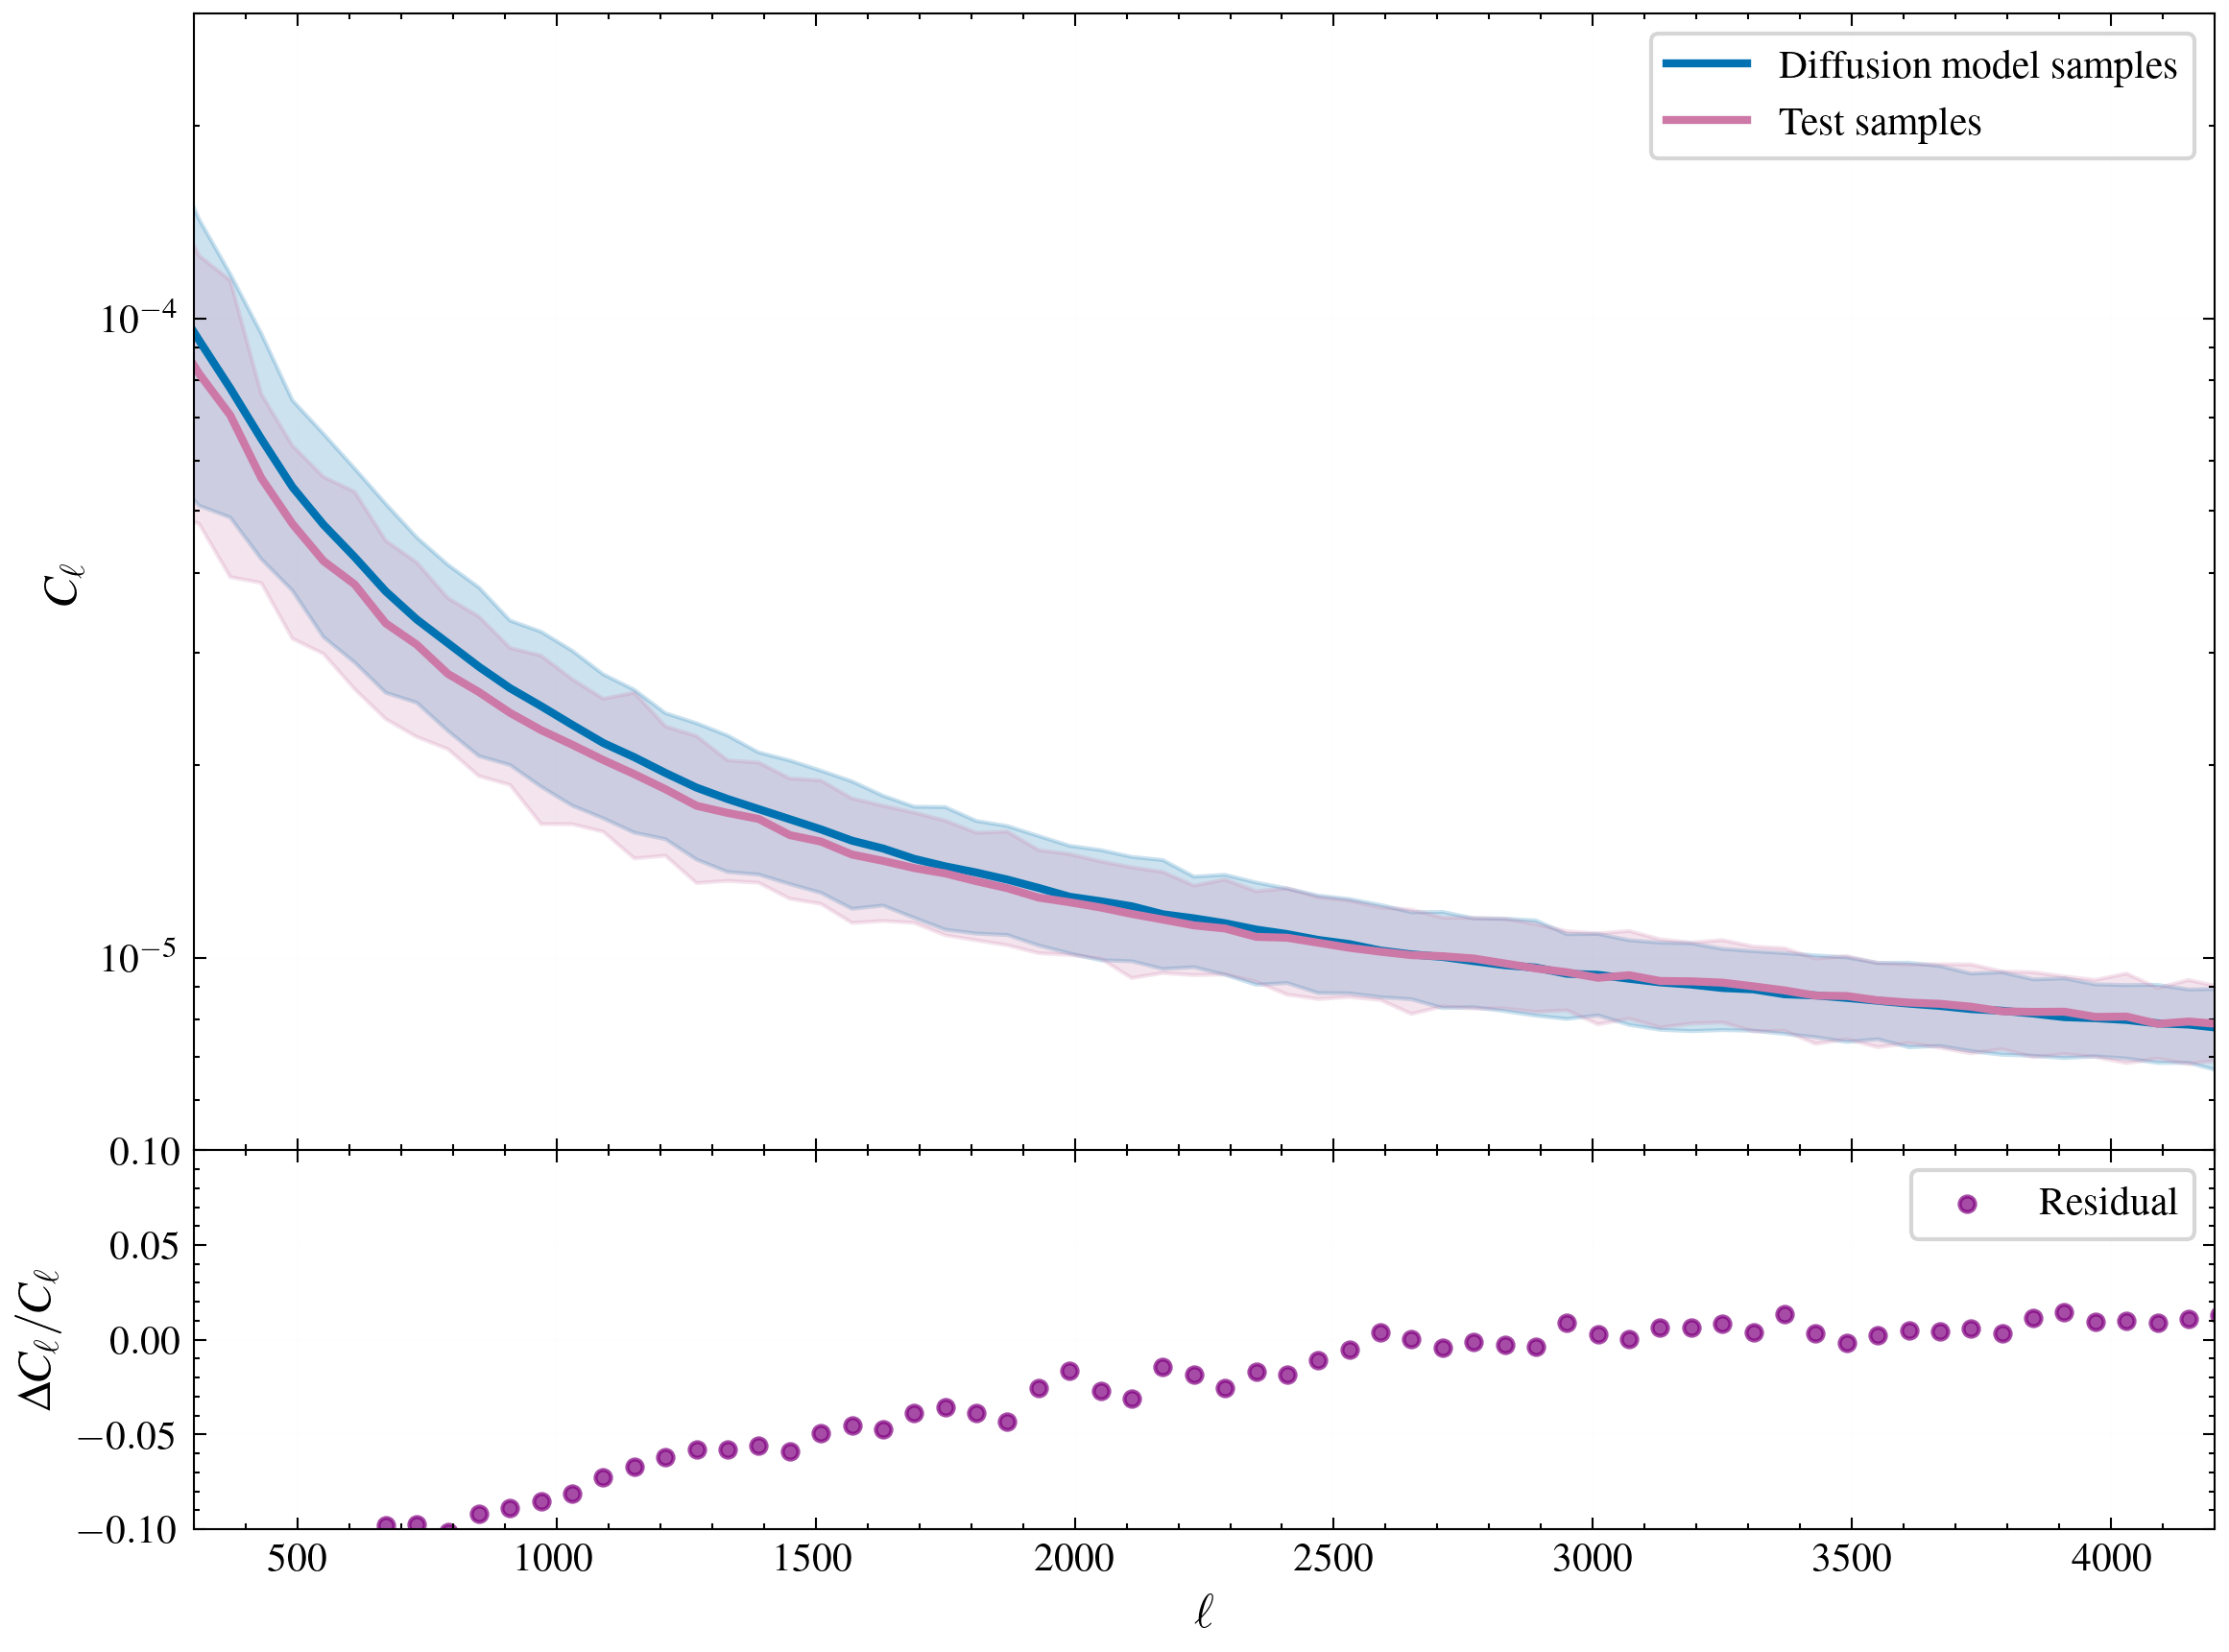

In [177]:
fig = plt.figure(figsize=(8,6))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

low_dm = np.percentile(cls_dm, 2.5, axis=0)
high_dm = np.percentile(cls_dm, 97.5, axis=0)

ax1.fill_between(el, low_dm, high_dm, color='#0072B2', alpha=0.2)
ax1.plot(el, np.mean(cls_dm, axis=0), color='#0072B2', lw=2, label="Diffusion model samples")

low_test = np.percentile(cls_test, 2.5, axis=0)
high_test = np.percentile(cls_test, 97.5, axis=0)

ax1.fill_between(el, low_test, high_test, color='#CC79A7', alpha=0.2,)
ax1.plot(el, np.mean(cls_test, axis=0), color='#CC79A7', lw=2, label="Test samples")

ax1.set_yscale('log')
ax1.set_xlim(300, 4200)
ax1.set_ylim(5e-6, 3e-4)
#ax1.set_ylim(5e-10, 3e-8)
ax1.set_ylabel(r"$C_\ell$", fontsize=12)

#ax1.grid(True, which='both',axis="both")
#ax1.grid(True, which='both', axis='both', lw= 0.5, alpha = 0.5)
ax1.legend(frameon=True, fontsize=10, loc='upper right')
plt.setp(ax1.get_xticklabels(), visible=False)
ax1.tick_params(axis='both', labelsize=10)

bias = (np.mean(cls_train, axis=0) - np.mean(cls_dm, axis=0)) / np.mean(cls_train, axis=0)
ax2.scatter(el, bias, marker='o', color='purple', alpha=0.7, s=15, label="Residual")
#ax2.grid(True, which='both', axis='both', lw= 0.1, alpha = 0.05)
ax2.set_xlabel(r"$\ell$", fontsize=12)
ax2.set_ylabel(r"$\Delta C_\ell / C_\ell$", fontsize=12)
ax2.set_ylim(-0.1, 0.1)
ax2.legend(frameon=True, fontsize=10, loc="upper right")
ax2.tick_params(axis='both', labelsize=10)

plt.tight_layout()
#plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/power_spectra_comparison_curve.png", dpi=200, bbox_inches="tight")
#plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/power_spectra_comparison_curve.pdf", dpi=200, bbox_inches="tight")
plt.show()

In [162]:
#200 vs all samples

In [178]:
pixels_training = training_images[:n_training_samples].flatten()
pixels_test = testing_images[:n_test_samples].flatten()
pixels_all_samples = all_samples[:n_training_samples].flatten()

bins = np.linspace(0, 100, 1000)
#bins = np.logspace(np.log10(1), np.log10(100.0), 1000)

bin_centers = (bins[:-1] + bins[1:]) / 2

hist_training, _ = np.histogram(pixels_training, bins=bins, density=True)
hist_test, _ = np.histogram(pixels_test, bins=bins, density=True)
hist_all_samples, _ = np.histogram(pixels_all_samples, bins=bins, density=True)

smooth_training = gaussian_filter1d(hist_training, sigma=1)
smooth_test = gaussian_filter1d(hist_test, sigma=1)
smooth_all_samples = gaussian_filter1d(hist_all_samples, sigma=1)

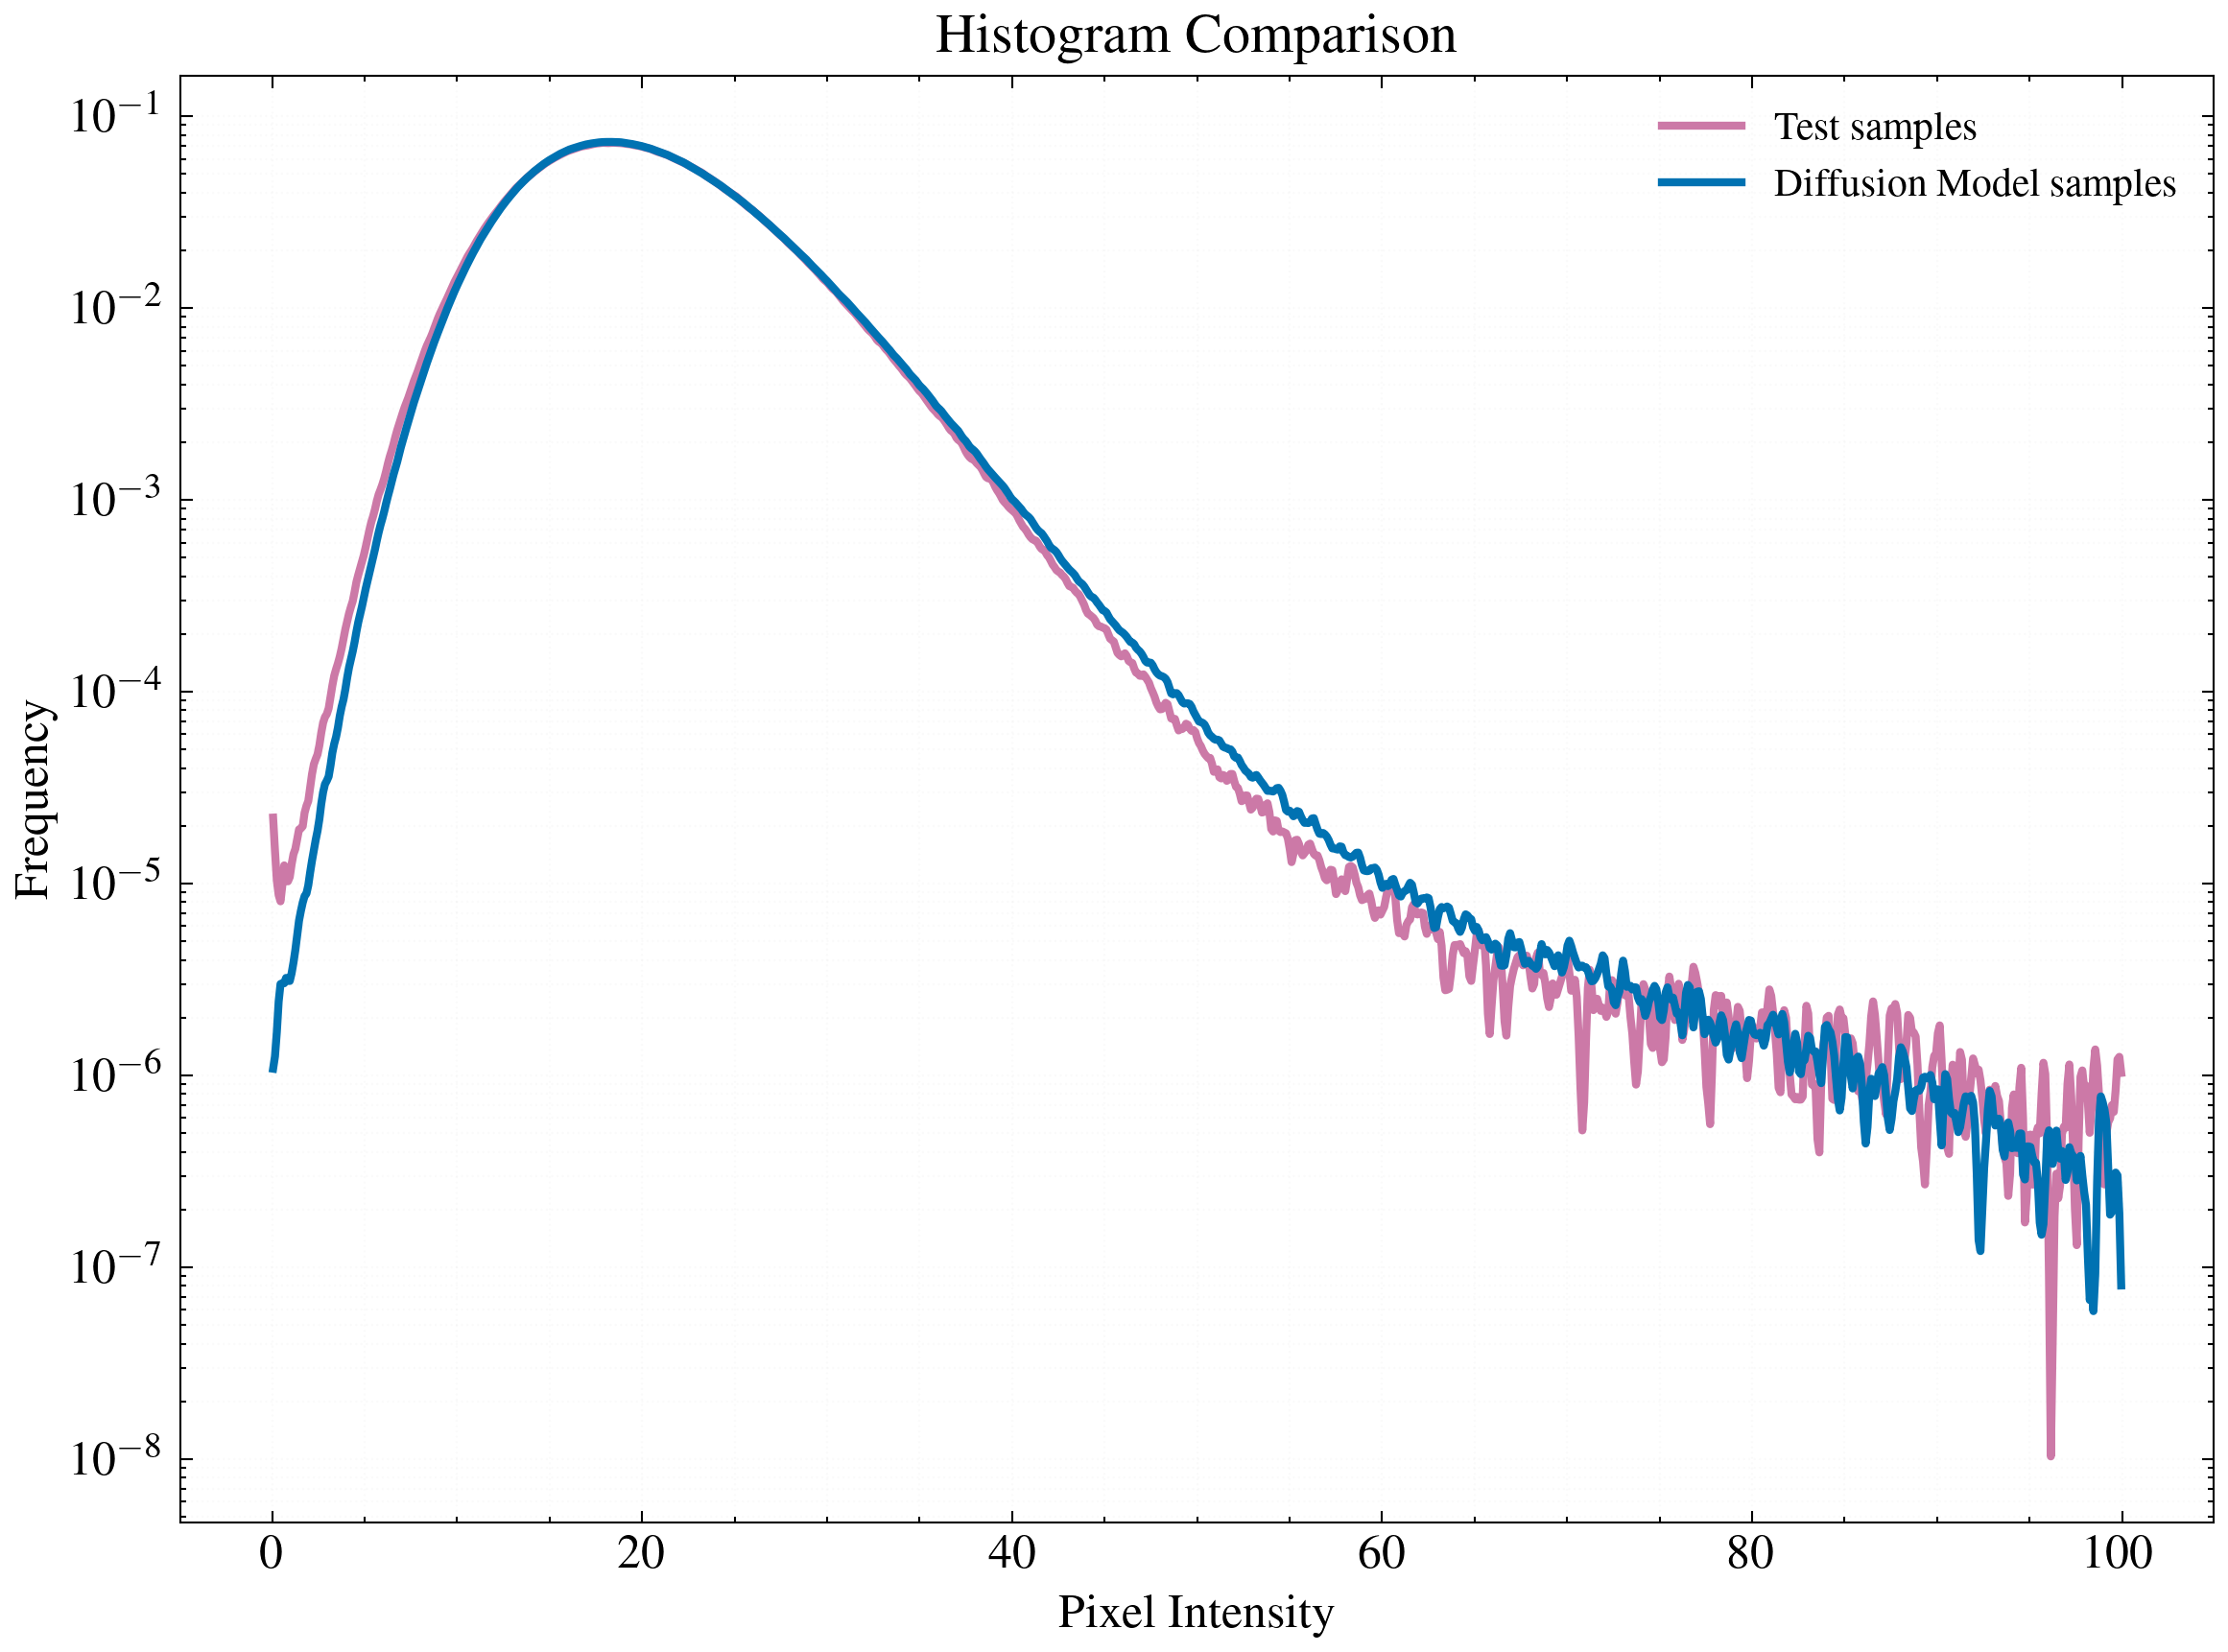

In [179]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(bin_centers, smooth_test, color='#CC79A7', lw=2, label='Test samples')
ax.plot(bin_centers, smooth_all_samples, color='#0072B2', lw=2, label='Diffusion Model samples')
#ax.plot(bin_centers, smooth_training, color='#009E73', lw=2, label='Training sample')

ax.set_title("Histogram Comparison", fontsize=14)
ax.set_xlabel("Pixel Intensity", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_yscale('log')
ax.grid(True, which='both', ls=':', lw=0.5)
ax.legend(loc="upper right", fontsize=10)

plt.tight_layout()
#plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/histogram_comparison_curve.pdf", dpi=200, bbox_inches="tight")
#plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/histogram_comparison_curve.png", dpi=200, bbox_inches="tight")
plt.show()

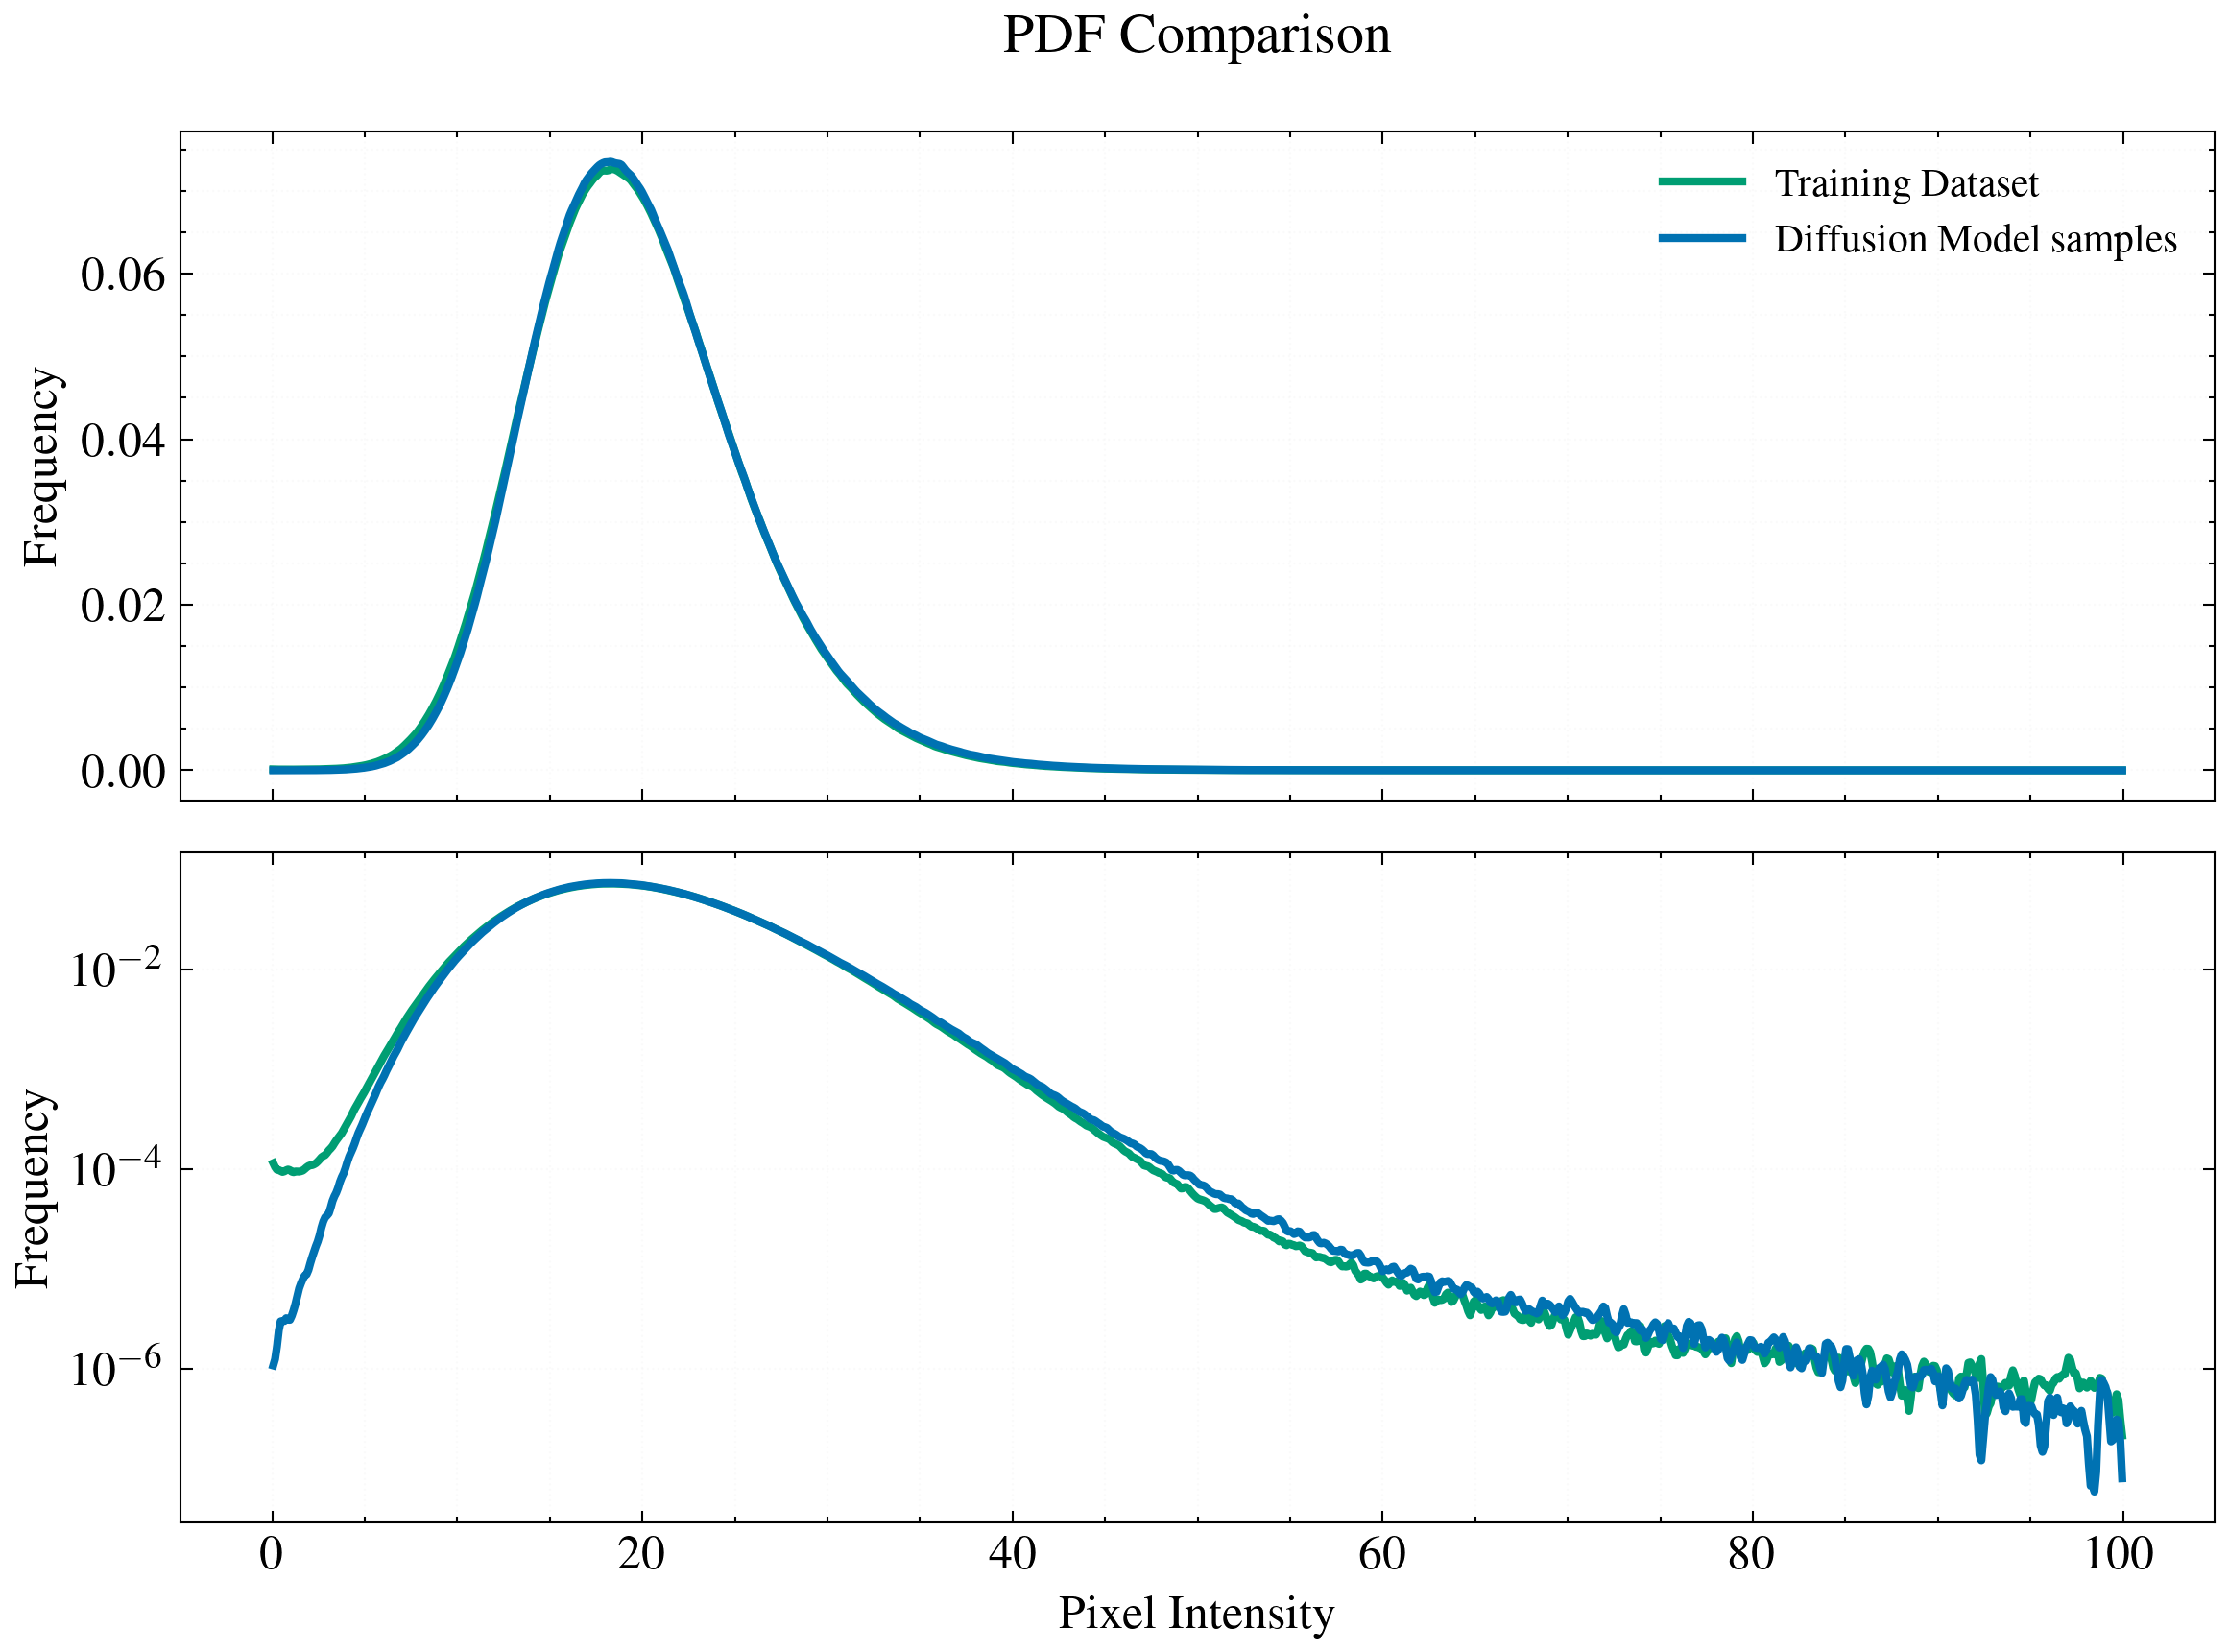

In [180]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
fig.subplots_adjust(hspace=0.15)  # Adjust vertical spacing

# Top panel (linear scale)
ax1.plot(bin_centers, smooth_training, color='#009E73', lw=2, label='Training Dataset')
ax1.plot(bin_centers, smooth_all_samples, color='#0072B2', lw=2, label='Diffusion Model samples')
ax1.set_ylabel("Frequency", fontsize=12)
ax1.grid(True, which='both', ls=':', lw=0.5)
ax1.legend(loc="upper right", fontsize=10)

# Bottom panel (log scale)
ax2.plot(bin_centers, smooth_training, color='#009E73', lw=2)
ax2.plot(bin_centers, smooth_all_samples, color='#0072B2', lw=2)
ax2.set_xlabel("Pixel Intensity", fontsize=12)
ax2.set_ylabel("Frequency", fontsize=12)
ax2.set_yscale('log')
ax2.grid(True, which='both', ls=':', lw=0.5)

# Common elements
ax1.set_title("PDF Comparison", fontsize=14, pad=20)
ax1.tick_params(axis='x', which='both', labelbottom=False)  # Hide x-ticks for top panel

plt.tight_layout()
#plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/histogram_comparison_curve_2panel.pdf", dpi=200, bbox_inches="tight")
#plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/histogram_comparison_curve_2panel.png", dpi=200, bbox_inches="tight")
plt.show()